# 1. System and Problem Definition

## Intelligent System: Bank Marketing Subscription Prediction

### Real-world problem

A bank conducts direct marketing campaigns to contact existing or potential clients.
The bank wants to identify which clients are likely to subscribe to a term deposit.

The objective of this intelligent system is to support marketing decisions by predicting
whether a client is likely to subscribe to a term deposit.

### Formal problem statement

Given the available client and campaign information for a previously unseen client,
predict whether that client will subscribe to a term deposit.

The learning task is a binary classification problem:

- `0` → client does not subscribe
- `1` → client subscribes

### Intelligent-system view

The system follows:

**Real-world client information → Feature Representation → Machine Learning Model → Prediction**

The system receives structured information, represents it as a numerical feature vector,
learns patterns from historical examples, and produces a prediction for a new client.

This assignment therefore develops a small intelligent system rather than only training
a machine-learning classifier.

# 2. Intelligent System Diagram

## System Architecture

```text
┌──────────────────────┐
│  Real-world Client   │
│  & Campaign Data     │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│   Input Information  │
│ age, job, education, │
│ contact, campaign... │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│ Feature Representation│
│ Numerical +           │
│ One-Hot Encoded       │
│ Features              │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│    Preprocessing      │
│ Scaling + Encoding    │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│   Traditional ML      │
│       Model            │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│      Prediction       │
│ Subscribe / Not       │
│ Subscribe             │
└──────────┬───────────┘
           │
           ▼
┌──────────────────────┐
│ Marketing Application │
│ / Decision Support    │
└──────────────────────┘


---

# 3. Dataset Source

## Dataset

**Bank Marketing Dataset**

### Kaggle source

https://www.kaggle.com/datasets/alexkataev/bank-marketing-data-set

### Original public source

UCI Machine Learning Repository:

https://archive.ics.uci.edu/dataset/222/bank+marketing

### File used

The notebook uses:

`bank-additional-full.csv`

The CSV file uses `;` as its separator.

### Why this dataset was selected

The dataset is appropriate for Assignment 01 because:

1. It represents a real-world business problem.
2. Each row represents an identifiable client-contact observation.
3. It contains both numerical and categorical features.
4. It has a clearly defined binary target.
5. It contains enough observations for meaningful experiments.
6. The problem is suitable for traditional machine learning.

# 4. Dataset Description

The Bank Marketing dataset contains records from direct marketing campaigns of a
Portuguese banking institution.

Each observation describes a client and information associated with a marketing campaign.

## Target

The target variable is:

`y`

where:

- `no` → the client did not subscribe to a term deposit
- `yes` → the client subscribed to a term deposit

## Feature Dictionary

| Feature | Type | Meaning |
|---|---|---|
| age | Numerical | Age of the client |
| job | Categorical | Type of job |
| marital | Categorical | Marital status |
| education | Categorical | Education level |
| default | Categorical | Whether the client has credit in default |
| housing | Categorical | Whether the client has a housing loan |
| loan | Categorical | Whether the client has a personal loan |
| contact | Categorical | Communication type |
| month | Categorical | Month of the last contact |
| day_of_week | Categorical | Day of the week of the last contact |
| campaign | Numerical | Number of contacts performed during the current campaign |
| pdays | Numerical | Number of days since the client was last contacted from a previous campaign |
| previous | Numerical | Number of contacts performed before the current campaign |
| poutcome | Categorical | Outcome of the previous marketing campaign |
| emp.var.rate | Numerical | Employment variation rate |
| cons.price.idx | Numerical | Consumer price index |
| cons.conf.idx | Numerical | Consumer confidence index |
| euribor3m | Numerical | 3-month Euribor rate |
| nr.employed | Numerical | Number of employees |

The complete dataset contains 41,188 observations and 20 input variables in
`bank-additional-full.csv`.

## Important modeling decision

The feature `duration` is excluded from the main predictive representation.

The reason is that `duration` represents the duration of the last contact and is only
known after the interaction has taken place. Including it would make a pre-interaction
customer targeting system less realistic.

Therefore, the main system predicts subscription using information available without
depending on the completed call duration.

In [4]:
# ============================================
# 5. DATA REPRESENTATION
# ============================================

import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

# -------------------------------------------------
# Load dataset
# -------------------------------------------------

possible_paths = [
    "bank-additional-full.csv",
    "./data/bank-additional-full.csv",
    "/kaggle/input/bank-marketing-data-set/bank-additional-full.csv",
    "/kaggle/input/bank-marketing-dataset/bank-additional-full.csv"
]

data_path = None

for path in possible_paths:
    if os.path.exists(path):
        data_path = path
        break

if data_path is None:
    raise FileNotFoundError(
        "Cannot find bank-additional-full.csv.\n"
        "Please download the dataset from Kaggle and place the CSV file "
        "in the same folder as this notebook."
    )

df = pd.read_csv(data_path, sep=";")

print("Dataset loaded successfully.")
print("File:", data_path)
print("Shape:", df.shape)

# -------------------------------------------------
# Define target
# -------------------------------------------------

TARGET = "y"

# Convert target:
# no  -> 0
# yes -> 1
y = df[TARGET].map({"no": 0, "yes": 1}).astype(int)

# -------------------------------------------------
# Main representation
# -------------------------------------------------

# duration is excluded for real-world validity
EXCLUDED_FEATURES = ["duration"]

feature_cols = [
    col for col in df.columns
    if col not in [TARGET] + EXCLUDED_FEATURES
]

X = df[feature_cols].copy()

# Identify numerical and categorical variables
numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(
    exclude=["number"]
).columns.tolist()

print("\nNumerical features:")
print(numeric_features)

print("\nCategorical features:")
print(categorical_features)

print("\nTarget:")
print(y.value_counts())

# -------------------------------------------------
# Representation summary
# -------------------------------------------------

representation_table = pd.DataFrame({
    "Feature": feature_cols,
    "Type": [
        "Numerical" if col in numeric_features else "Categorical"
        for col in feature_cols
    ],
    "Model Representation": [
        "Standardized numerical value"
        if col in numeric_features
        else "One-hot encoded categorical value"
        for col in feature_cols
    ]
})

display(representation_table)

# -------------------------------------------------
# Preprocessing pipeline
# -------------------------------------------------

try:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", encoder, categorical_features)
    ],
    remainder="drop"
)

print("\nRepresentation pipeline created.")
print("""
Representation transformation:

Raw client record
        ↓
Numerical features
        ↓
Standardization
        ↓
Categorical features
        ↓
One-hot encoding
        ↓
Final numerical feature vector
        ↓
Traditional ML model

Important principle:
The model does not receive the real-world client directly.
It receives only the selected computational representation.
""")

Dataset loaded successfully.
File: bank-additional-full.csv
Shape: (41188, 21)

Numerical features:
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']

Target:
y
0    36548
1     4640
Name: count, dtype: int64


,Feature,Type,Model Representation
0,age,Numerical,Standardized numerical value
1,job,Categorical,One-hot encoded categorical value
2,marital,Categorical,One-hot encoded categorical value
3,education,Categorical,One-hot encoded categorical value
4,default,Categorical,One-hot encoded categorical value
5,housing,Categorical,One-hot encoded categorical value
6,loan,Categorical,One-hot encoded categorical value
7,contact,Categorical,One-hot encoded categorical value
8,month,Categorical,One-hot encoded categorical value
9,day_of_week,Categorical,One-hot encoded categorical value



Representation pipeline created.

Representation transformation:

Raw client record
        ↓
Numerical features
        ↓
Standardization
        ↓
Categorical features
        ↓
One-hot encoding
        ↓
Final numerical feature vector
        ↓
Traditional ML model

Important principle:
The model does not receive the real-world client directly.
It receives only the selected computational representation.



In [5]:
# ============================================
# 6. FEATURE AND TARGET ANALYSIS
# ============================================
print("""
FORMAL LEARNING PROBLEM

For each observation:

x_i ∈ R^d

where x_i is the numerical representation of one client.

The supervised dataset is:

D = {(x_i, y_i)} for i = 1,...,N

where:

x_i = input feature vector
y_i ∈ {0,1} = target class
N = number of observations
d = number of original model features

The model learns:

ŷ = f_θ(x)

where θ represents the learned model parameters.

This is a binary classification problem because the target
contains two possible classes: 0 and 1.
""")
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nMissing values:")
missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values.to_frame(name="Missing Values"))

print("\nTarget distribution:")
target_counts = df["y"].value_counts()
display(target_counts.to_frame(name="Count"))

print("\nTarget distribution (%):")
target_percent = (
    df["y"].value_counts(normalize=True) * 100
).round(2)

display(target_percent.to_frame(name="Percentage"))

print("\nNumber of observations:", len(df))
print("Number of raw features:", len(df.columns) - 1)
print("Number of model features after removing duration:", len(feature_cols))
print("Number of numerical features:", len(numeric_features))
print("Number of categorical features:", len(categorical_features))

print("\nFeature summary:")
display(representation_table)


FORMAL LEARNING PROBLEM

For each observation:

x_i ∈ R^d

where x_i is the numerical representation of one client.

The supervised dataset is:

D = {(x_i, y_i)} for i = 1,...,N

where:

x_i = input feature vector
y_i ∈ {0,1} = target class
N = number of observations
d = number of original model features

The model learns:

ŷ = f_θ(x)

where θ represents the learned model parameters.

This is a binary classification problem because the target
contains two possible classes: 0 and 1.

Dataset shape:
(41188, 21)

Column names:
['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']

Data types:


,Data Type
age,int64
job,str
marital,str
education,str
default,str
housing,str
loan,str
contact,str
month,str
day_of_week,str



Missing values:


,Missing Values
age,0
job,0
marital,0
education,0
default,0
housing,0
loan,0
contact,0
month,0
day_of_week,0



Target distribution:


,Count
y,
no,36548
yes,4640



Target distribution (%):


,Percentage
y,
no,88.73
yes,11.27



Number of observations: 41188
Number of raw features: 20
Number of model features after removing duration: 19
Number of numerical features: 9
Number of categorical features: 10

Feature summary:


,Feature,Type,Model Representation
0,age,Numerical,Standardized numerical value
1,job,Categorical,One-hot encoded categorical value
2,marital,Categorical,One-hot encoded categorical value
3,education,Categorical,One-hot encoded categorical value
4,default,Categorical,One-hot encoded categorical value
5,housing,Categorical,One-hot encoded categorical value
6,loan,Categorical,One-hot encoded categorical value
7,contact,Categorical,One-hot encoded categorical value
8,month,Categorical,One-hot encoded categorical value
9,day_of_week,Categorical,One-hot encoded categorical value


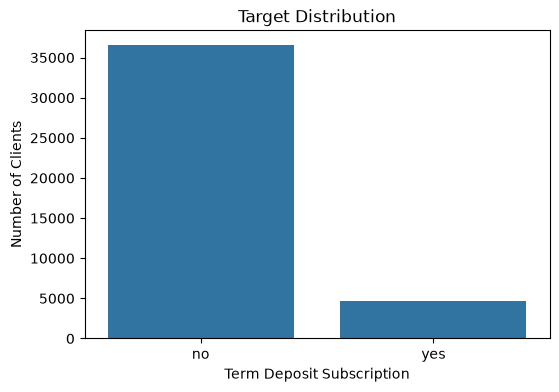

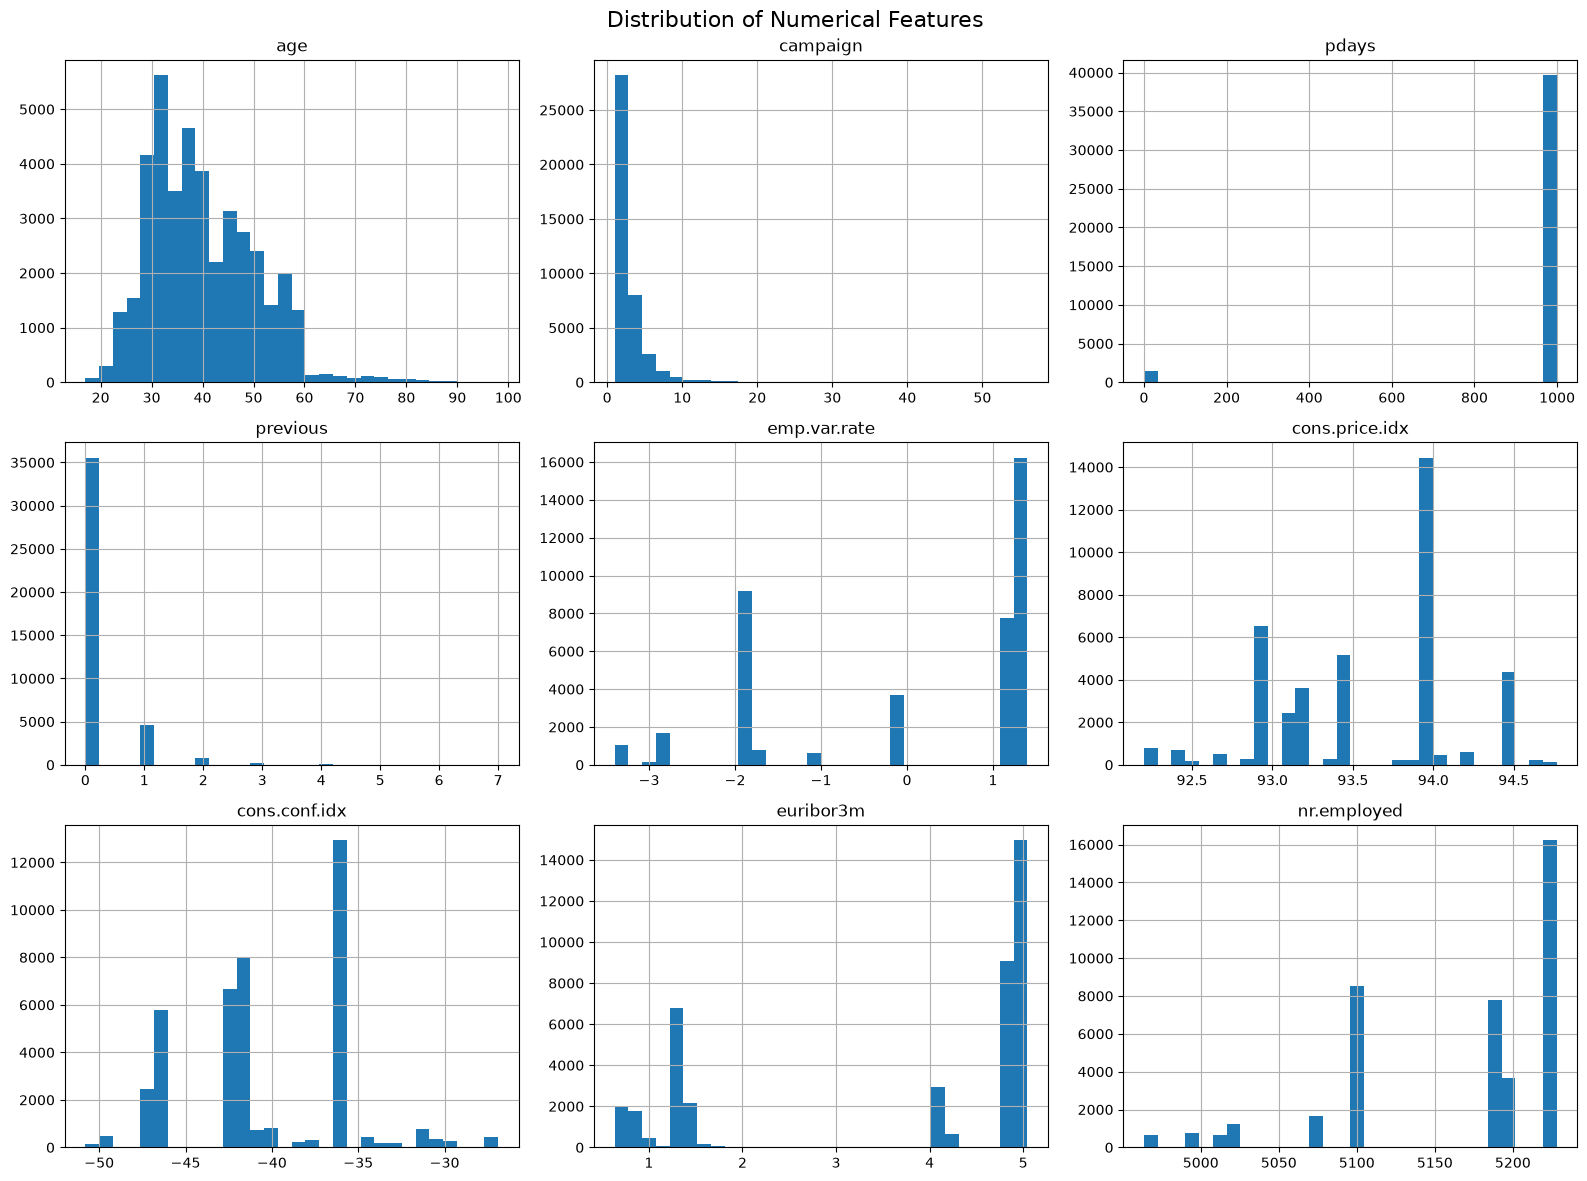

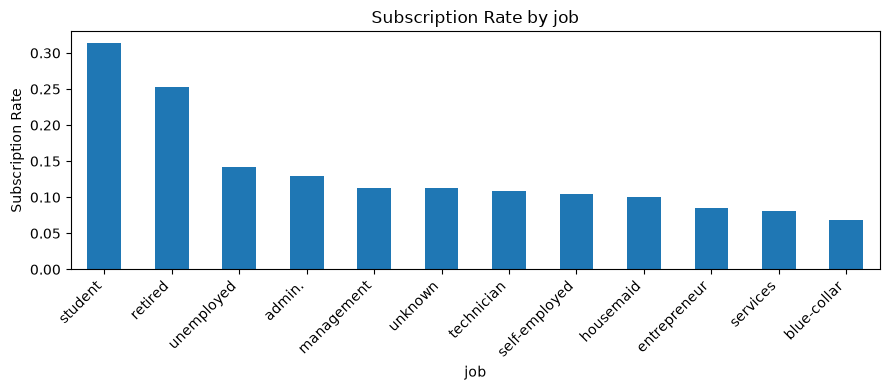

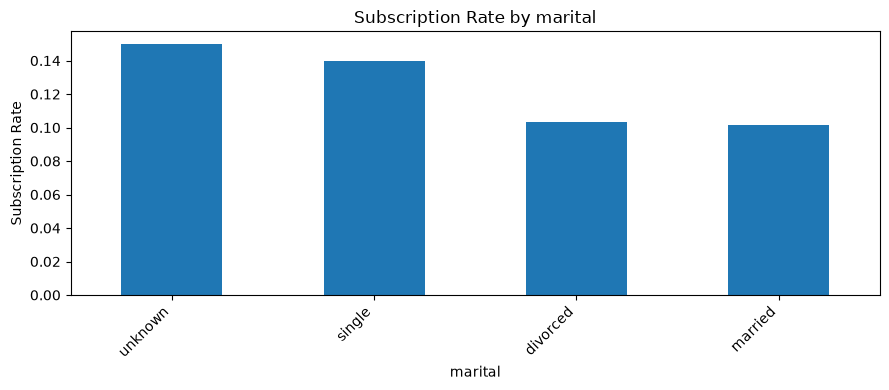

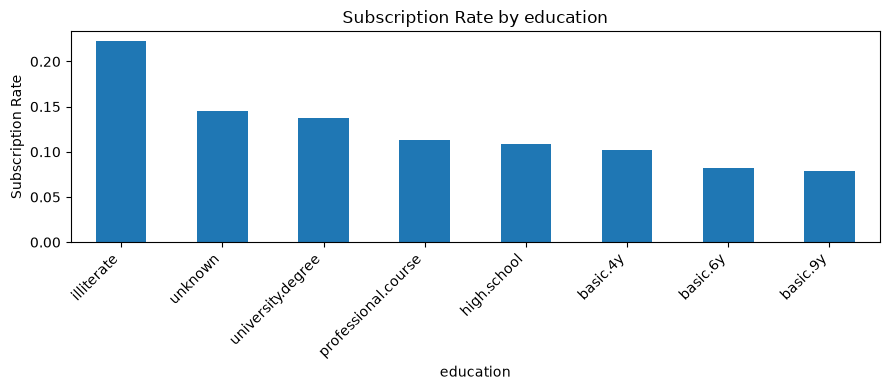

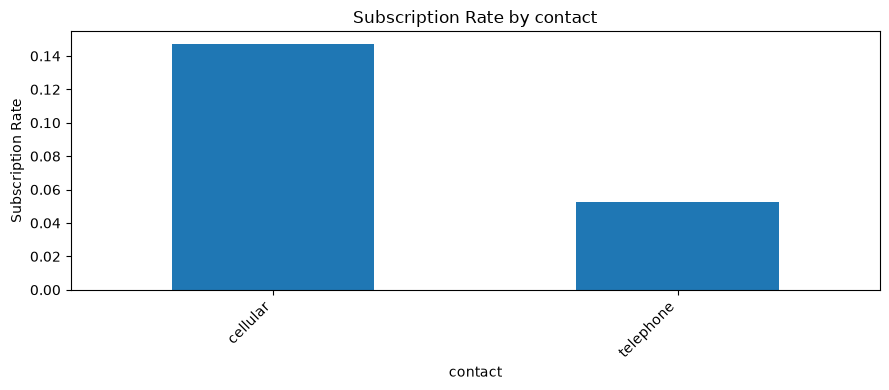

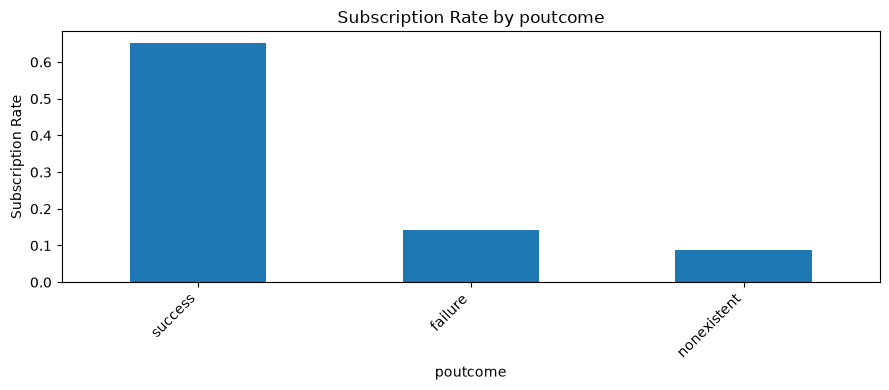

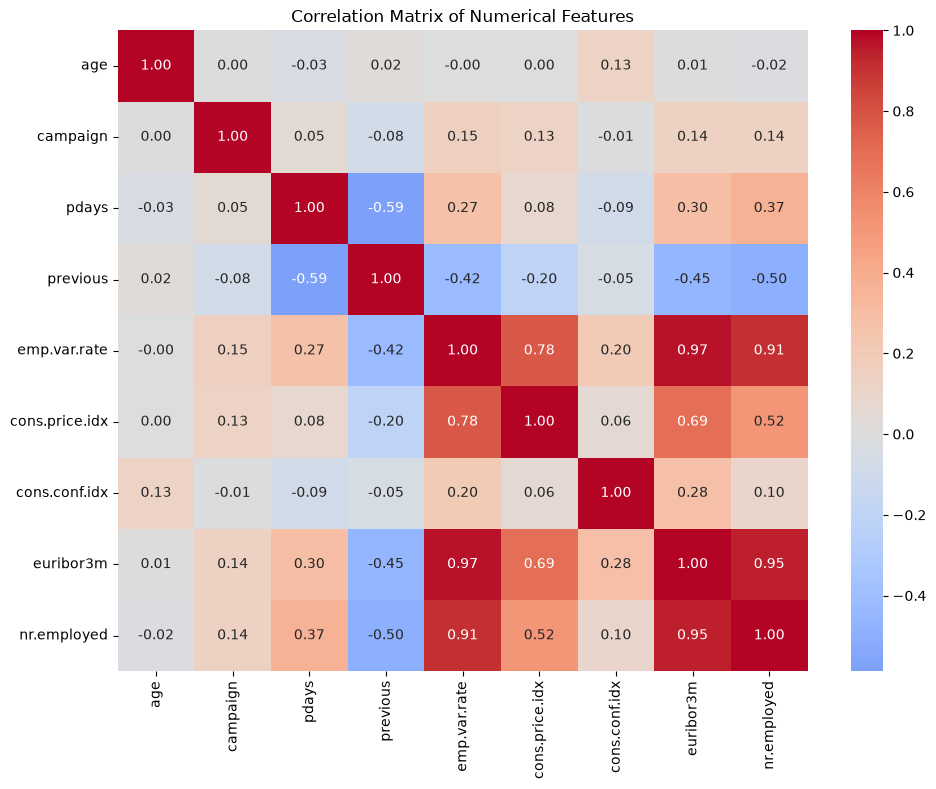

In [6]:
# ============================================
# 7. EXPLORATORY DATA ANALYSIS
# ============================================

# ----------------------------
# 7.1 Target distribution
# ----------------------------

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="y")
plt.title("Target Distribution")
plt.xlabel("Term Deposit Subscription")
plt.ylabel("Number of Clients")
plt.show()


# ----------------------------
# 7.2 Numerical distributions
# ----------------------------

df[numeric_features].hist(
    figsize=(16, 12),
    bins=30
)

plt.suptitle(
    "Distribution of Numerical Features",
    fontsize=16
)

plt.tight_layout()
plt.show()


# ----------------------------
# 7.3 Subscription rate by selected categories
# ----------------------------

selected_categories = [
    "job",
    "marital",
    "education",
    "contact",
    "poutcome"
]

for column in selected_categories:

    subscription_rate = (
        df.groupby(column)["y"]
        .apply(lambda x: (x == "yes").mean())
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(9, 4))

    subscription_rate.plot(kind="bar")

    plt.title(
        f"Subscription Rate by {column}"
    )

    plt.ylabel("Subscription Rate")
    plt.xlabel(column)
    plt.xticks(rotation=45, ha="right")

    plt.tight_layout()
    plt.show()


# ----------------------------
# 7.4 Correlation matrix
# ----------------------------

corr = df[numeric_features].corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix of Numerical Features")
plt.tight_layout()
plt.show()

In [7]:
# ============================================
# 8. TRAIN / TEST SPLIT
# ============================================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:")
print(X_train.shape)

print("\nTest set shape:")
print(X_test.shape)

print("\nTraining target distribution:")
display(
    y_train.value_counts(normalize=True)
    .rename("Proportion")
)

print("\nTest target distribution:")
display(
    y_test.value_counts(normalize=True)
    .rename("Proportion")
)

Training set shape:
(32950, 19)

Test set shape:
(8238, 19)

Training target distribution:


y
0    0.887344
1    0.112656
Name: Proportion, dtype: float64


Test target distribution:


y
0    0.887351
1    0.112649
Name: Proportion, dtype: float64

In [8]:
# ============================================
# 9. BASELINE
# ============================================

from sklearn.dummy import DummyClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

baseline = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        DummyClassifier(strategy="most_frequent")
    )
])

baseline_scores = cross_validate(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    n_jobs=-1
)

baseline_result = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Baseline Score": [
        baseline_scores["test_accuracy"].mean(),
        baseline_scores["test_precision"].mean(),
        baseline_scores["test_recall"].mean(),
        baseline_scores["test_f1"].mean()
    ]
})

display(
    baseline_result.style.format({
        "Baseline Score": "{:.4f}"
    })
)

print(
    """
Why is a baseline necessary?

The baseline provides the first reference point.
It tells us how well a simple strategy performs without
learning meaningful relationships from the input features.

A useful machine-learning model should demonstrate
meaningful improvement over this baseline.
"""
)

,Metric,Baseline Score
0,Accuracy,0.8873
1,Precision,0.0000
2,Recall,0.0000
3,F1,0.0000



Why is a baseline necessary?

The baseline provides the first reference point.
It tells us how well a simple strategy performs without
learning meaningful relationships from the input features.

A useful machine-learning model should demonstrate
meaningful improvement over this baseline.



In [9]:
# ============================================
# 10. MODEL 1 — LOGISTIC REGRESSION
# ============================================

from sklearn.linear_model import LogisticRegression

model_1 = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE
        )
    )
])

model_1.fit(X_train, y_train)

y_pred_1 = model_1.predict(X_test)

print("Model 1: Logistic Regression")
print("Model trained successfully.")
print("Number of test predictions:", len(y_pred_1))

Model 1: Logistic Regression
Model trained successfully.
Number of test predictions: 8238


In [10]:
# ============================================
# 11. MODEL 2 — K-NEAREST NEIGHBORS
# ============================================

from sklearn.neighbors import KNeighborsClassifier

model_2 = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=19
        )
    )
])

model_2.fit(X_train, y_train)

y_pred_2 = model_2.predict(X_test)

print("Model 2: K-Nearest Neighbors")
print("Initial k =", 19)
print("Model trained successfully.")
print("Number of test predictions:", len(y_pred_2))

Model 2: K-Nearest Neighbors
Initial k = 19
Model trained successfully.
Number of test predictions: 8238


In [11]:
# ============================================
# 12. MODEL 3 — DECISION TREE
# ============================================

from sklearn.tree import DecisionTreeClassifier

model_3 = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        DecisionTreeClassifier(
            max_depth=8,
            min_samples_leaf=10,
            random_state=RANDOM_STATE
        )
    )
])

model_3.fit(X_train, y_train)

y_pred_3 = model_3.predict(X_test)

print("Model 3: Decision Tree")
print("max_depth =", 8)
print("min_samples_leaf =", 10)
print("Model trained successfully.")
print("Number of test predictions:", len(y_pred_3))

Model 3: Decision Tree
max_depth = 8
min_samples_leaf = 10
Model trained successfully.
Number of test predictions: 8238


In [12]:
# ============================================
# 13. MODEL 4 — RANDOM FOREST
# ============================================

from sklearn.ensemble import RandomForestClassifier

model_4 = Pipeline([
    ("preprocess", preprocessor),
    (
        "model",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=12,
            min_samples_leaf=5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    )
])

model_4.fit(X_train, y_train)

y_pred_4 = model_4.predict(X_test)

print("Model 4: Random Forest")
print("n_estimators =", 200)
print("max_depth =", 12)
print("min_samples_leaf =", 5)
print("Model trained successfully.")
print("Number of test predictions:", len(y_pred_4))

Model 4: Random Forest
n_estimators = 200
max_depth = 12
min_samples_leaf = 5
Model trained successfully.
Number of test predictions: 8238


,Model,Accuracy,Precision,Recall,F1
0,Logistic Regression,0.9009,0.6905,0.2188,0.3322
1,KNN,0.9002,0.6550,0.2414,0.3528
2,Decision Tree,0.8984,0.6275,0.2414,0.3486
3,Random Forest,0.9018,0.6809,0.2414,0.3564


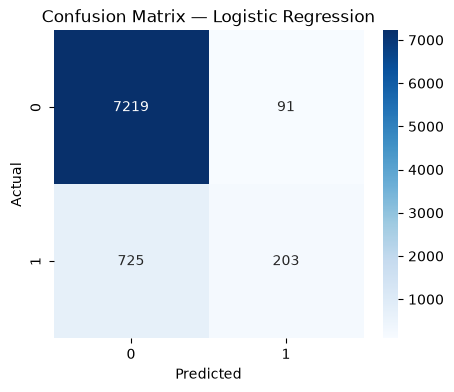

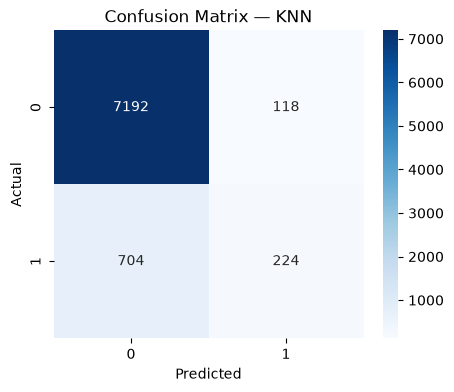

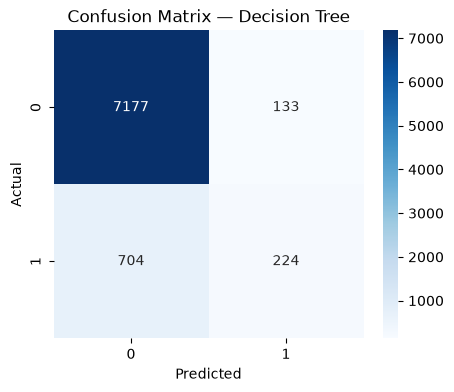

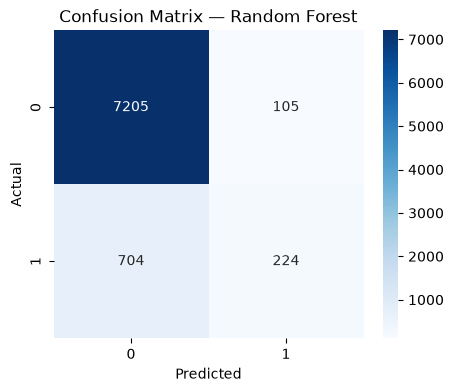


Logistic Regression
                 precision    recall  f1-score   support

No Subscription       0.91      0.99      0.95      7310
   Subscription       0.69      0.22      0.33       928

       accuracy                           0.90      8238
      macro avg       0.80      0.60      0.64      8238
   weighted avg       0.88      0.90      0.88      8238


KNN
                 precision    recall  f1-score   support

No Subscription       0.91      0.98      0.95      7310
   Subscription       0.65      0.24      0.35       928

       accuracy                           0.90      8238
      macro avg       0.78      0.61      0.65      8238
   weighted avg       0.88      0.90      0.88      8238


Decision Tree
                 precision    recall  f1-score   support

No Subscription       0.91      0.98      0.94      7310
   Subscription       0.63      0.24      0.35       928

       accuracy                           0.90      8238
      macro avg       0.77      0.61   

In [13]:
# ============================================
# 14. EVALUATION
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

models = {
    "Logistic Regression": model_1,
    "KNN": model_2,
    "Decision Tree": model_3,
    "Random Forest": model_4
}

evaluation_results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    evaluation_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            y_pred,
            zero_division=0
        ),
        "F1": f1_score(
            y_test,
            y_pred,
            zero_division=0
        )
    })

evaluation_df = pd.DataFrame(evaluation_results)

display(
    evaluation_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

# ----------------------------
# Confusion matrices
# ----------------------------

for name, model in models.items():

    y_pred = model.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

# ----------------------------
# Detailed reports
# ----------------------------

for name, model in models.items():

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            model.predict(X_test),
            target_names=[
                "No Subscription",
                "Subscription"
            ],
            zero_division=0
        )
    )

print("""
METRIC INTERPRETATION

Accuracy:
Measures the overall proportion of correct predictions.

Precision:
Among clients predicted as subscribers, measures how many
actually subscribed.

Recall:
Among clients who actually subscribed, measures how many
were correctly identified.

F1-score:
Combines Precision and Recall into a single balanced measure.

Confusion Matrix:
Shows TP, TN, FP, and FN directly.

Why Accuracy alone is not sufficient:
The dataset is highly imbalanced. A majority-class baseline
already achieves approximately 88.7% accuracy while producing
zero Recall and zero F1 for the positive class.

Therefore, F1 is used as the primary model-selection metric,
while Accuracy, Precision, Recall and the Confusion Matrix
are also reported.
""")

In [14]:
# ============================================
# 15. EXPERIMENT 1 — MODEL COMPARISON
# ============================================

from sklearn.model_selection import cross_validate

print(
    """
Experimental Question:

Under the same preprocessing and the same
5-fold cross-validation protocol, which of the
four traditional ML models provides the best
overall classification performance?
"""
)

experiment_1_results = []

for name, model in models.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    experiment_1_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

experiment_1_df = pd.DataFrame(
    experiment_1_results
).sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

display(
    experiment_1_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

best_model_experiment_1 = experiment_1_df.iloc[0]["Model"]

print(
    "\nBest model according to cross-validated F1:",
    best_model_experiment_1
)
print("""
SCIENTIFIC ANALYSIS

The four models receive the same underlying feature
representation, but they impose different assumptions.

Logistic Regression learns a relatively simple linear
relationship between the input representation and the
probability of subscription.

KNN relies on similarity between nearby observations.
Therefore, feature scaling is especially important because
distance calculations are affected by numerical scale.

Decision Tree can model nonlinear decision boundaries by
recursively splitting the feature space.

Random Forest combines many decision trees and can model
complex nonlinear relationships more robustly.

The model with the highest F1-score is preferred for the
main application because the positive class is relatively
rare and the application requires a balance between finding
potential subscribers and avoiding excessive false positives.

The results should therefore be interpreted using multiple
metrics rather than Accuracy alone.
""")


Experimental Question:

Under the same preprocessing and the same
5-fold cross-validation protocol, which of the
four traditional ML models provides the best
overall classification performance?



,Model,Accuracy,Precision,Recall,F1
0,Decision Tree,0.8975,0.6072,0.2581,0.3620
1,KNN,0.8988,0.6283,0.2511,0.3584
2,Random Forest,0.8999,0.6643,0.2263,0.3372
3,Logistic Regression,0.8995,0.6564,0.2268,0.3370



Best model according to cross-validated F1: Decision Tree

SCIENTIFIC ANALYSIS

The four models receive the same underlying feature
representation, but they impose different assumptions.

Logistic Regression learns a relatively simple linear
relationship between the input representation and the
probability of subscription.

KNN relies on similarity between nearby observations.
Therefore, feature scaling is especially important because
distance calculations are affected by numerical scale.

Decision Tree can model nonlinear decision boundaries by
recursively splitting the feature space.

Random Forest combines many decision trees and can model
complex nonlinear relationships more robustly.

The model with the highest F1-score is preferred for the
main application because the positive class is relatively
rare and the application requires a balance between finding
potential subscribers and avoiding excessive false positives.

The results should therefore be interpreted using multiple
met


Experimental Question:

How does the KNN hyperparameter k affect
classification performance?

Only k is changed. The preprocessing,
training data, and cross-validation protocol
remain fixed.



,k,Accuracy,Precision,Recall,F1
0,3,0.8812,0.4568,0.2842,0.3502
1,5,0.8898,0.5215,0.2753,0.3603
2,7,0.8937,0.5581,0.2740,0.3671
3,9,0.8947,0.5716,0.2627,0.3597
4,11,0.8962,0.5885,0.2624,0.3625
5,15,0.8967,0.6003,0.2495,0.3522
6,19,0.8988,0.6283,0.2511,0.3584
7,25,0.8987,0.6332,0.2403,0.3480
8,31,0.8997,0.6514,0.2371,0.3471



Best k according to cross-validated F1: 7


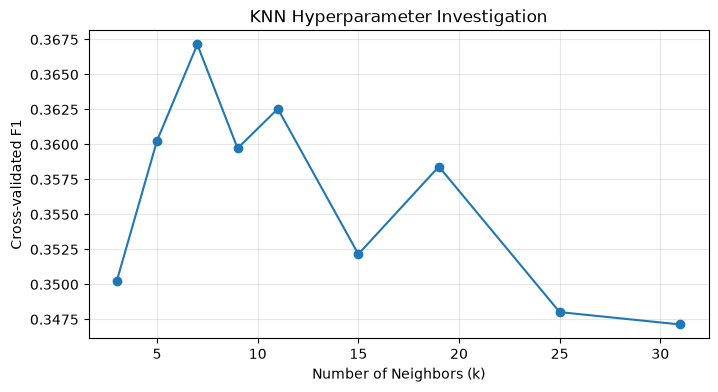

In [15]:
# ============================================
# 16. EXPERIMENT 2 — HYPERPARAMETER INVESTIGATION
# ============================================

print(
    """
Experimental Question:

How does the KNN hyperparameter k affect
classification performance?

Only k is changed. The preprocessing,
training data, and cross-validation protocol
remain fixed.
"""
)

k_values = [
    3, 5, 7, 9,
    11, 15, 19,
    25, 31
]

experiment_2_results = []

for k in k_values:

    knn_model = Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=k
            )
        )
    ])

    scores = cross_validate(
        knn_model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    experiment_2_results.append({
        "k": k,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

experiment_2_df = pd.DataFrame(
    experiment_2_results
)

display(
    experiment_2_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

best_k = int(
    experiment_2_df.loc[
        experiment_2_df["F1"].idxmax(),
        "k"
    ]
)

print("\nBest k according to cross-validated F1:", best_k)

plt.figure(figsize=(8, 4))

plt.plot(
    experiment_2_df["k"],
    experiment_2_df["F1"],
    marker="o"
)

plt.xlabel("Number of Neighbors (k)")
plt.ylabel("Cross-validated F1")
plt.title("KNN Hyperparameter Investigation")

plt.grid(True, alpha=0.3)
plt.show()

In [16]:
# ============================================
# 17. EXPERIMENT 3 — REPRESENTATION INVESTIGATION
# ============================================

print(
    """
Experimental Question:

Does standardizing numerical features improve
KNN performance compared with using unscaled
numerical features?

Only the numerical representation changes.
The KNN hyperparameter k and the evaluation
protocol remain fixed.
"""
)

# -------------------------------------------------
# Representation A:
# Numerical features are standardized
# -------------------------------------------------

try:
    encoder_scaled = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder_scaled = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor_scaled = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            encoder_scaled,
            categorical_features
        )
    ]
)

knn_scaled = Pipeline([
    ("preprocess", preprocessor_scaled),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=best_k
        )
    )
])

# -------------------------------------------------
# Representation B:
# Numerical features are NOT standardized
# -------------------------------------------------

try:
    encoder_unscaled = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    encoder_unscaled = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

preprocessor_unscaled = ColumnTransformer(
    transformers=[
        (
            "num",
            "passthrough",
            numeric_features
        ),
        (
            "cat",
            encoder_unscaled,
            categorical_features
        )
    ]
)

knn_unscaled = Pipeline([
    ("preprocess", preprocessor_unscaled),
    (
        "model",
        KNeighborsClassifier(
            n_neighbors=best_k
        )
    )
])

# -------------------------------------------------
# Evaluate both representations
# -------------------------------------------------

scaled_scores = cross_validate(
    knn_scaled,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    n_jobs=-1
)

unscaled_scores = cross_validate(
    knn_unscaled,
    X_train,
    y_train,
    cv=cv,
    scoring=[
        "accuracy",
        "precision",
        "recall",
        "f1"
    ],
    n_jobs=-1
)

experiment_3_df = pd.DataFrame({
    "Representation": [
        "Scaled numerical features",
        "Unscaled numerical features"
    ],
    "Accuracy": [
        scaled_scores["test_accuracy"].mean(),
        unscaled_scores["test_accuracy"].mean()
    ],
    "Precision": [
        scaled_scores["test_precision"].mean(),
        unscaled_scores["test_precision"].mean()
    ],
    "Recall": [
        scaled_scores["test_recall"].mean(),
        unscaled_scores["test_recall"].mean()
    ],
    "F1": [
        scaled_scores["test_f1"].mean(),
        unscaled_scores["test_f1"].mean()
    ]
})

display(
    experiment_3_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)


Experimental Question:

Does standardizing numerical features improve
KNN performance compared with using unscaled
numerical features?

Only the numerical representation changes.
The KNN hyperparameter k and the evaluation
protocol remain fixed.



,Representation,Accuracy,Precision,Recall,F1
0,Scaled numerical features,0.8937,0.5581,0.2740,0.3671
1,Unscaled numerical features,0.8902,0.5256,0.2664,0.3535



Final-model selection principle:

The final model is selected using evidence
from the training set and cross-validation.

The test set is not repeatedly used to select
the model.



,Model,Accuracy,Precision,Recall,F1
0,KNN,0.8937,0.5581,0.2740,0.3671
1,Decision Tree,0.8975,0.6072,0.2581,0.3620
2,Random Forest,0.8999,0.6643,0.2263,0.3372
3,Logistic Regression,0.8995,0.6564,0.2268,0.3370



Selected final model: KNN


,Metric,Test Score
0,Accuracy,0.8994
1,Precision,0.6122
2,Recall,0.2909
3,F1,0.3944


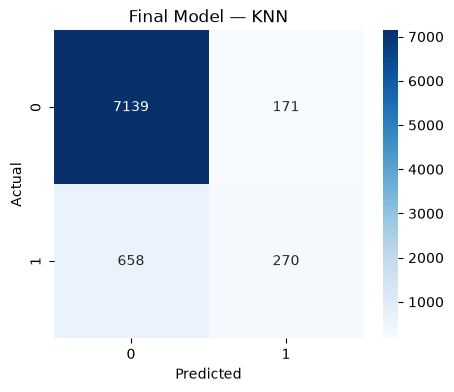


FINAL MODEL SELECTION

Selected model: KNN

The model was selected using cross-validation on the
training set.

Primary selection metric: F1-score

Reason:
The target is highly imbalanced, and the application is
interested in identifying potential subscribers. Therefore,
a balance between Precision and Recall is more informative
than Accuracy alone.

The test set was not used during model selection.

Its only purpose is the final hold-out evaluation of the
selected model.

Model saved successfully.


In [17]:
# ============================================
# 18. FINAL MODEL
# ============================================

print(
    """
Final-model selection principle:

The final model is selected using evidence
from the training set and cross-validation.

The test set is not repeatedly used to select
the model.
"""
)

# -------------------------------------------------
# Build final candidates
# -------------------------------------------------

final_candidates = {
    "Logistic Regression": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "KNN": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            KNeighborsClassifier(
                n_neighbors=best_k
            )
        )
    ]),

    "Decision Tree": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                max_depth=8,
                min_samples_leaf=10,
                random_state=RANDOM_STATE
            )
        )
    ]),

    "Random Forest": Pipeline([
        ("preprocess", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=200,
                max_depth=12,
                min_samples_leaf=5,
                random_state=RANDOM_STATE,
                n_jobs=-1
            )
        )
    ])
}

# -------------------------------------------------
# Cross-validation model selection
# -------------------------------------------------

final_selection_results = []

for name, model in final_candidates.items():

    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=[
            "accuracy",
            "precision",
            "recall",
            "f1"
        ],
        n_jobs=-1
    )

    final_selection_results.append({
        "Model": name,
        "Accuracy": scores["test_accuracy"].mean(),
        "Precision": scores["test_precision"].mean(),
        "Recall": scores["test_recall"].mean(),
        "F1": scores["test_f1"].mean()
    })

final_selection_df = pd.DataFrame(
    final_selection_results
).sort_values(
    by="F1",
    ascending=False
).reset_index(drop=True)

display(
    final_selection_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1": "{:.4f}"
    })
)

# -------------------------------------------------
# Select final model
# -------------------------------------------------

final_model_name = final_selection_df.iloc[0]["Model"]

final_model = final_candidates[
    final_model_name
]

print(
    "\nSelected final model:",
    final_model_name
)

# -------------------------------------------------
# Train final model on the complete training set
# -------------------------------------------------

final_model.fit(
    X_train,
    y_train
)

# -------------------------------------------------
# Final hold-out test evaluation
# -------------------------------------------------

y_final_pred = final_model.predict(
    X_test
)

final_accuracy = accuracy_score(
    y_test,
    y_final_pred
)

final_precision = precision_score(
    y_test,
    y_final_pred,
    zero_division=0
)

final_recall = recall_score(
    y_test,
    y_final_pred,
    zero_division=0
)

final_f1 = f1_score(
    y_test,
    y_final_pred,
    zero_division=0
)

final_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1"
    ],
    "Test Score": [
        final_accuracy,
        final_precision,
        final_recall,
        final_f1
    ]
})

display(
    final_metrics.style.format({
        "Test Score": "{:.4f}"
    })
)

# -------------------------------------------------
# Final confusion matrix
# -------------------------------------------------

final_cm = confusion_matrix(
    y_test,
    y_final_pred
)

plt.figure(figsize=(5, 4))

sns.heatmap(
    final_cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(
    f"Final Model — {final_model_name}"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

print(f"""
FINAL MODEL SELECTION

Selected model: {final_model_name}

The model was selected using cross-validation on the
training set.

Primary selection metric: F1-score

Reason:
The target is highly imbalanced, and the application is
interested in identifying potential subscribers. Therefore,
a balance between Precision and Recall is more informative
than Accuracy alone.

The test set was not used during model selection.

Its only purpose is the final hold-out evaluation of the
selected model.
""")
import joblib

joblib.dump(
    final_model,
    "bank_marketing_model.pkl"
)

print("Model saved successfully.")

In [18]:
# ============================================
# 19. APPLICATION
# ============================================

print(
    """
Application pipeline:

User Input
    ↓
Feature Representation
    ↓
Preprocessing
    ↓
Final ML Model
    ↓
Prediction
    ↓
Output
"""
)

def predict_subscription(client_data):
    """
    Predict whether a client is likely to subscribe
    to a term deposit.

    client_data must contain the same model features
    used during training.
    """

    # Convert dictionary to a one-row DataFrame
    sample = pd.DataFrame(
        [client_data]
    )

    # Make prediction
    prediction = final_model.predict(
        sample
    )[0]

    # Create human-readable result
    if prediction == 1:
        result = "Likely to subscribe"
    else:
        result = "Likely not to subscribe"

    output = {
        "Prediction": int(prediction),
        "Result": result
    }

    # Probability if supported by the final model
    if hasattr(
        final_model,
        "predict_proba"
    ):
        probability = final_model.predict_proba(
            sample
        )[0]

        output["Probability_No"] = float(
            probability[0]
        )

        output["Probability_Yes"] = float(
            probability[1]
        )

    return output


# Example application input
example_client = X_test.iloc[0].to_dict()

example_result = predict_subscription(
    example_client
)

print("Example client:")
display(
    pd.DataFrame([example_client])
)

print("\nApplication output:")
print(example_result)


Application pipeline:

User Input
    ↓
Feature Representation
    ↓
Preprocessing
    ↓
Final ML Model
    ↓
Prediction
    ↓
Output

Example client:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
0,32,management,divorced,university.degree,no,no,no,cellular,jul,tue,5,999,0,nonexistent,1.4,93.918,-42.7,4.961,5228.1



Application output:
{'Prediction': 0, 'Result': 'Likely not to subscribe', 'Probability_No': 0.8571428571428571, 'Probability_Yes': 0.14285714285714285}


In [19]:
# ============================================
# 20. SYSTEM DEMONSTRATION
# ============================================

print(
    """
System Demonstration

The following three cases are taken from the
held-out test set.

They were NOT used to train the final model.
Each case passes through the complete pipeline:

Input → Representation → Preprocessing
→ Final Model → Prediction
"""
)

# Take three unseen test cases
demo_indices = X_test.index[:3]

demo_results = []

for case_number, index in enumerate(
    demo_indices,
    start=1
):

    client_data = X_test.loc[
        index
    ].to_dict()

    result = predict_subscription(
        client_data
    )

    true_label = int(
        y_test.loc[index]
    )

    true_text = (
        "Subscription"
        if true_label == 1
        else "No Subscription"
    )

    demo_results.append({
        "Case": case_number,
        "Predicted Class": result["Result"],
        "Predicted Probability of Subscription":
            result.get(
                "Probability_Yes",
                np.nan
            ),
        "Actual Class": true_text
    })

demo_df = pd.DataFrame(
    demo_results
)

display(
    demo_df.style.format({
        "Predicted Probability of Subscription":
            "{:.2%}"
    })
)

print(
    """
The demonstration shows that the trained model
can receive a previously unseen feature vector,
apply the same preprocessing used during training,
and produce a prediction for the client.
"""
)


System Demonstration

The following three cases are taken from the
held-out test set.

They were NOT used to train the final model.
Each case passes through the complete pipeline:

Input → Representation → Preprocessing
→ Final Model → Prediction



,Case,Predicted Class,Predicted Probability of Subscription,Actual Class
0,1,Likely not to subscribe,14.29%,No Subscription
1,2,Likely not to subscribe,42.86%,No Subscription
2,3,Likely not to subscribe,42.86%,No Subscription



The demonstration shows that the trained model
can receive a previously unseen feature vector,
apply the same preprocessing used during training,
and produce a prediction for the client.



# 21. Reflection

## 21.1 What information does the system receive?

The system receives structured client and marketing-campaign information such as age,
job, education, previous campaign information, contact information, and economic
indicators.

## 21.2 What is the internal representation?

The raw structured information is converted into a numerical feature vector.

Numerical features are standardized and categorical features are converted using
one-hot encoding.

Therefore, the model does not directly receive the original raw record.

## 21.3 What does the model learn from examples?

The model learns statistical relationships between the feature representation and the
target variable.

The target represents whether the client subscribed to a term deposit.

## 21.4 What prediction does the system make?

The system produces a binary prediction:

- `0` → no subscription
- `1` → subscription

## 21.5 Why can it handle an unseen input?

The model is trained using many historical observations.

After learning a relationship between input representations and target values, it can
apply that learned relationship to a previously unseen observation.

This is the generalization capability of supervised learning.

## 21.6 What part of the system can reasonably be called intelligent?

The predictive component demonstrates a limited operational form of intelligence:

**learning from examples + generalization + prediction**

However, the model does not independently understand the whole real world.

## 21.7 What are the limitations?

Several limitations remain:

1. The system depends on the quality and representativeness of the dataset.
2. Historical relationships may not remain valid when the environment changes.
3. The chosen feature representation determines what information is available to the model.
4. The model does not reason about the wider world.
5. The model does not automatically adapt to changes in customer behavior.
6. The system does not contain human-level understanding, memory, or general reasoning.

## 21.8 Reflection on representation

The feature-vector representation preserves measurable structured information about
clients and campaigns.

However, it may lose:

- rich conversational information;
- temporal interaction sequences;
- relationships between clients;
- unstructured text;
- other contextual information.

The same business problem could later be represented using:

- sequences;
- graphs;
- embeddings;
- multimodal representations.

A change in representation would potentially require different learning methods.

This demonstrates the central course principle:

**Different information representations → different learning methods.**

# 22. Conclusion

This assignment developed a small intelligent system for Bank Marketing subscription
prediction.

The complete development pipeline was:

**Real-world problem**
→ **Structured data**
→ **Feature representation**
→ **Preprocessing**
→ **Traditional ML models**
→ **Controlled experiments**
→ **Evaluation**
→ **Final model**
→ **Application**
→ **Prediction**

The assignment demonstrated that developing an intelligent system is not simply a
matter of calling `fit()` on a machine-learning algorithm.

The development process also requires:

- understanding the real-world problem;
- defining the input and target;
- choosing an appropriate representation;
- comparing multiple models;
- establishing a baseline;
- conducting controlled experiments;
- selecting an appropriate evaluation metric;
- analyzing the results;
- deploying the final model in an application.

The main conceptual lesson is:

**Understand → Represent → Implement → Experiment → Evaluate → Apply**

The trained ML model is only one component of the intelligent system.

The complete system includes the data, representation, preprocessing, learned model,
prediction mechanism, and application interface.

